In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("Starting Analysis of Web Attack Dataset...\n")

Starting Analysis of Web Attack Dataset...



In [67]:
df_train = pd.read_csv('/home/rashid/Documents/FYP/Ai-Augumented-IDS/train_attacks_only.csv')
df_test = pd.read_csv('/home/rashid/Documents/FYP/Ai-Augumented-IDS/test_attacks_only.csv')

print(f"Train samples: {len(df_train)}")
print(f"Test samples: {len(df_test)}")

Train samples: 20052
Test samples: 5013


In [68]:
def get_attack_type(row):
    has_sqli = (row.get('query_has_sqli', 0) > 0 or row.get('body_has_sqli', 0) > 0)
    has_xss  = (row.get('query_has_xss', 0) > 0 or row.get('body_has_xss', 0) > 0)
    has_trav = (row.get('query_has_traversal', 0) > 0 or row.get('body_has_traversal', 0) > 0)
    
    if has_trav:               # check traversal FIRST
        return 'PATH_TRAVERSAL'
    elif has_sqli:
        return 'SQLI'
    elif has_xss:
        return 'XSS'
    else:
        return 'OTHER'

# Apply to both train and test
df_train['attack_type'] = df_train.apply(get_attack_type, axis=1)
df_test['attack_type'] = df_test.apply(get_attack_type, axis=1)

# Show distribution
print("=== TRAIN SET ATTACK TYPE DISTRIBUTION ===")
train_attack_counts = df_train['attack_type'].value_counts()
train_attack_percent = df_train['attack_type'].value_counts(normalize=True) * 100
print(train_attack_counts)
print("\nPercentage:")
print(train_attack_percent.round(2))

print("\n=== TEST SET ATTACK TYPE DISTRIBUTION ===")
test_attack_counts = df_test['attack_type'].value_counts()
test_attack_percent = df_test['attack_type'].value_counts(normalize=True) * 100
print(test_attack_counts)
print("\nPercentage:")
print(test_attack_percent.round(2))

# Path Traversal Statistics
print("\n=== PATH TRAVERSAL STATISTICS ===")
train_path_traversal = train_attack_counts.get('PATH_TRAVERSAL', 0)
test_path_traversal = test_attack_counts.get('PATH_TRAVERSAL', 0)
train_path_percent = train_attack_percent.get('PATH_TRAVERSAL', 0)
test_path_percent = test_attack_percent.get('PATH_TRAVERSAL', 0)

print(f"Train - Path Traversal: {train_path_traversal} ({train_path_percent:.2f}%)")
print(f"Test - Path Traversal: {test_path_traversal} ({test_path_percent:.2f}%)")
print(f"Total Path Traversal: {train_path_traversal + test_path_traversal}")

=== TRAIN SET ATTACK TYPE DISTRIBUTION ===
attack_type
OTHER             16493
SQLI               3246
XSS                 159
PATH_TRAVERSAL      154
Name: count, dtype: int64

Percentage:
attack_type
OTHER             82.25
SQLI              16.19
XSS                0.79
PATH_TRAVERSAL     0.77
Name: proportion, dtype: float64

=== TEST SET ATTACK TYPE DISTRIBUTION ===
attack_type
OTHER             4108
SQLI               828
PATH_TRAVERSAL      40
XSS                 37
Name: count, dtype: int64

Percentage:
attack_type
OTHER             81.95
SQLI              16.52
PATH_TRAVERSAL     0.80
XSS                0.74
Name: proportion, dtype: float64

=== PATH TRAVERSAL STATISTICS ===
Train - Path Traversal: 154 (0.77%)
Test - Path Traversal: 40 (0.80%)
Total Path Traversal: 194


In [69]:
# Define feature engineering function
def engineer_features(df):
    df['sqli_equals_density'] = df['query_num_equals'] / (df['query_length'] + 1e-5)
    df['sqli_special_ratio']  = df['query_num_special'] / (df['query_length'] + 1e-5)
    df['sqli_tautology_proxy'] = ((df['query_has_sqli'] > 0) & (df['query_num_equals'] > 2)).astype(int)

    df['xss_special_ratio']   = df['query_num_special'] / (df['query_length'] + 1e-5)
    df['xss_bracket_proxy']   = ((df['query_has_xss'] > 0) & (df['query_num_special'] > 4)).astype(int)

    df['traversal_depth_ratio'] = df['url_path_depth'] / (df['url_length'] + 1e-5)
    df['traversal_dots_ratio']  = df['url_num_dots'] / (df['url_length'] + 1e-5)
    df['traversal_proxy']       = ((df['query_has_traversal'] > 0) | (df['body_has_traversal'] > 0)).astype(int)

    df['encoding_intensity']     = df['url_num_percent'] + df['query_num_percent'] + df['body_num_percent']
    df['double_encoding_flag']   = (df['url_has_double_encoding'] > 0).astype(int)
    df['high_entropy_query']     = (df['query_entropy'] > 4.5).astype(int)
    df['high_entropy_body']      = (df['body_entropy'] > 4.5).astype(int)
    df['entropy_spike_query']    = (df['query_entropy'] - df['url_entropy']).clip(lower=0)

    df['method_body_mismatch']   = ((df['method_get'] > 0) & (df['body_length'] > 20)).astype(int)
    df['post_no_content_type']   = ((df['method_post'] > 0) & (df['content_type_is_none'] > 0)).astype(int)

    df['special_char_density_query'] = df['query_num_special'] / (df['query_length'] + 1e-5)
    df['special_char_density_body']  = df['body_num_special'] / (df['body_length'] + 1e-5)
    
    return df

# Apply feature engineering to both datasets
df_train = engineer_features(df_train)
df_test = engineer_features(df_test)

print("Feature engineering completed for both train and test sets")
print(f"Train features: {df_train.shape[1]}")
print(f"Test features: {df_test.shape[1]}")

Feature engineering completed for both train and test sets
Train features: 71
Test features: 71


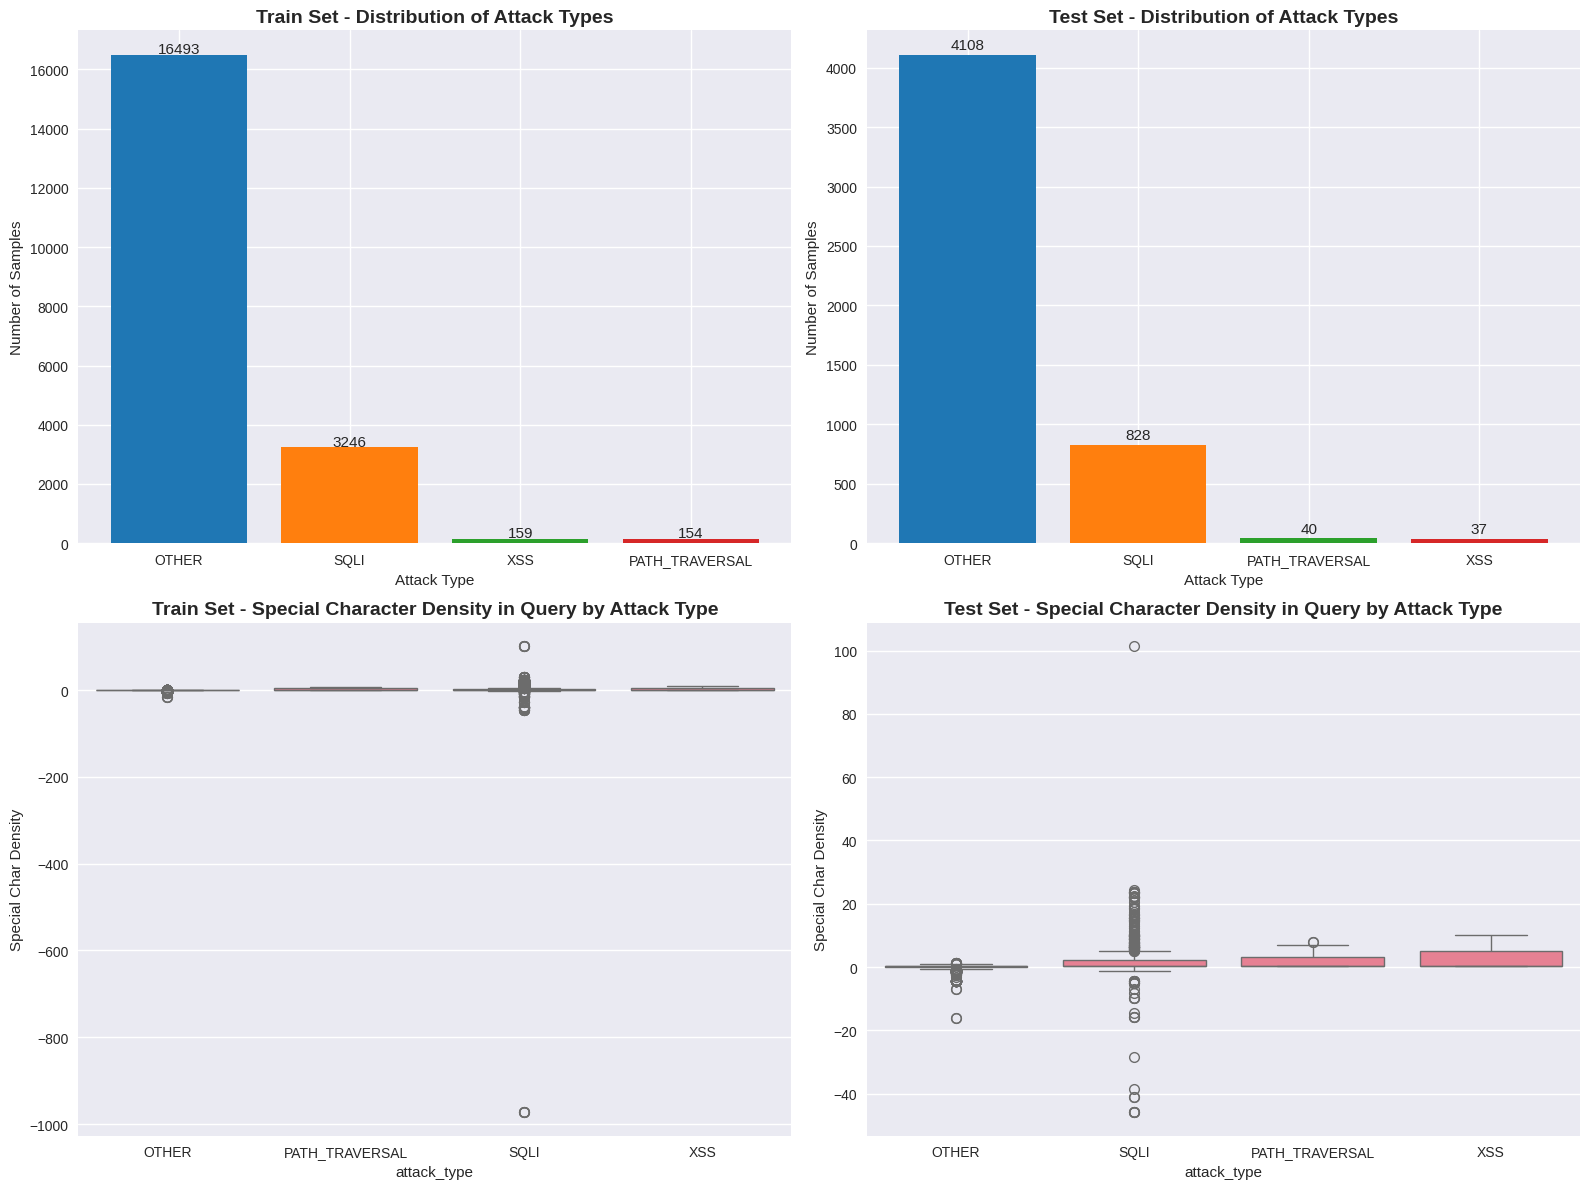


Analysis and plots completed!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].bar(train_attack_counts.index, train_attack_counts.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0,0].set_title('Train Set - Distribution of Attack Types', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Number of Samples')
axes[0,0].set_xlabel('Attack Type')
for i, v in enumerate(train_attack_counts.values):
    axes[0,0].text(i, v + 50, str(v), ha='center', fontsize=11)


axes[0,1].bar(test_attack_counts.index, test_attack_counts.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0,1].set_title('Test Set - Distribution of Attack Types', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Number of Samples')
axes[0,1].set_xlabel('Attack Type')
for i, v in enumerate(test_attack_counts.values):
    axes[0,1].text(i, v + 50, str(v), ha='center', fontsize=11)

# Plot 3: Train Special Character Density (Boxplot)
sns.boxplot(data=df_train, x='attack_type', y='special_char_density_query', ax=axes[1,0])
axes[1,0].set_title('Train Set - Special Character Density in Query by Attack Type', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Special Char Density')

# Plot 4: Test Special Character Density (Boxplot)
sns.boxplot(data=df_test, x='attack_type', y='special_char_density_query', ax=axes[1,1])
axes[1,1].set_title('Test Set - Special Character Density in Query by Attack Type', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Special Char Density')

plt.tight_layout()
plt.show()

print("\nAnalysis and plots complet")

In [71]:
leakage_cols = [
    'query_has_sqli', 'body_has_sqli',
    'query_has_xss', 'body_has_xss',
    'query_has_traversal', 'body_has_traversal'
]

proxy_cols = [
    'sqli_tautology_proxy',
    'xss_bracket_proxy',
    'traversal_proxy'
]

df_train = df_train.drop(columns=leakage_cols + proxy_cols)
df_test = df_test.drop(columns=leakage_cols + proxy_cols)

In [72]:
drop_cols = ['label', 'attack_type',
             'url_num_special', 'body_num_quotes', 'body_num_semicolons',
             'body_num_brackets', 'method_suspicious', 'cookie_length',
             'cookie_has_sqli', 'cookie_has_xss', 'cookie_is_present',
             'content_type_is_json', 'connection_is_close', 'connection_keep_alive',
             'post_no_content_type', 'get_with_body', 'post_empty_body',
             'content_length_mismatch']

# Prepare train data
X_train = df_train.drop(columns=drop_cols)
y_train = df_train['attack_type']

# Prepare test data
X_test = df_test.drop(columns=drop_cols)
y_test = df_test['attack_type']

# Map to integers
label_mapping = {'OTHER': 0, 'SQLI': 1, 'XSS': 2, 'PATH_TRAVERSAL': 3}
y_train_encoded = y_train.map(label_mapping)
y_test_encoded = y_test.map(label_mapping)

print(f"Train features: {X_train.shape}")
print(f"Test features: {X_test.shape}")

Train features: (20052, 44)
Test features: (5013, 44)


In [73]:
class_counts = y_train_encoded.value_counts()
total_samples = len(y_train_encoded)
n_classes = len(label_mapping)

# Higher weight for rare classes in training set
w_train = y_train_encoded.map(lambda cls: total_samples / (n_classes * class_counts[cls]))

print("Sample weights calculated for training set")

Sample weights calculated for training set


In [74]:
# Use predetermined train and test sets directly - no further splitting
print(f"Using predetermined train/test split")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Using predetermined train/test split
Training samples: 20052
Test samples: 5013


In [75]:
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    n_estimators=400,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    tree_method='hist',
    random_state=42,
    verbosity=1
)

model.fit(
    X_train, y_train_encoded,
    sample_weight=w_train,
    eval_set=[(X_test, y_test_encoded)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.85
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [76]:
y_pred = model.predict(X_test)

print("\n" + "="*60)
print("CLASSIFICATION REPORT (with sample weights)")
print("="*60)
print(classification_report(y_test_encoded, y_pred, target_names=list(label_mapping.keys()), labels=sorted(label_mapping.values())))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred, labels=sorted(label_mapping.values())))


importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 15 Important Features:")
print(importances.head(15))


CLASSIFICATION REPORT (with sample weights)
                precision    recall  f1-score   support

         OTHER       0.99      0.98      0.98      4108
          SQLI       0.91      0.93      0.92       828
           XSS       1.00      0.97      0.99        37
PATH_TRAVERSAL       1.00      1.00      1.00        40

      accuracy                           0.97      5013
     macro avg       0.97      0.97      0.97      5013
  weighted avg       0.97      0.97      0.97      5013


Confusion Matrix:
[[4032   76    0    0]
 [  57  771    0    0]
 [   0    1   36    0]
 [   0    0    0   40]]

Top 15 Important Features:
body_has_encoding             0.337602
url_num_dots                  0.261440
body_num_special              0.067148
url_num_hyphens               0.052333
special_char_density_query    0.047199
query_num_special             0.039588
encoding_intensity            0.038346
xss_special_ratio             0.036288
sqli_special_ratio            0.025807
traversal_dot

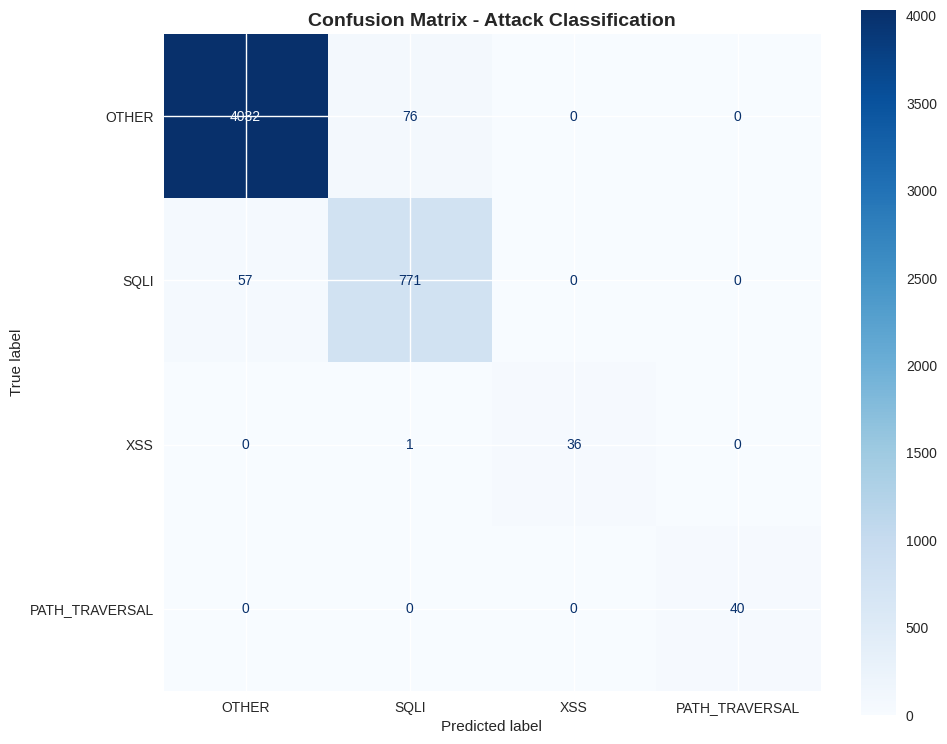

In [77]:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test_encoded, y_pred, labels=sorted(label_mapping.values()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label_mapping.keys()))
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix - Attack Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

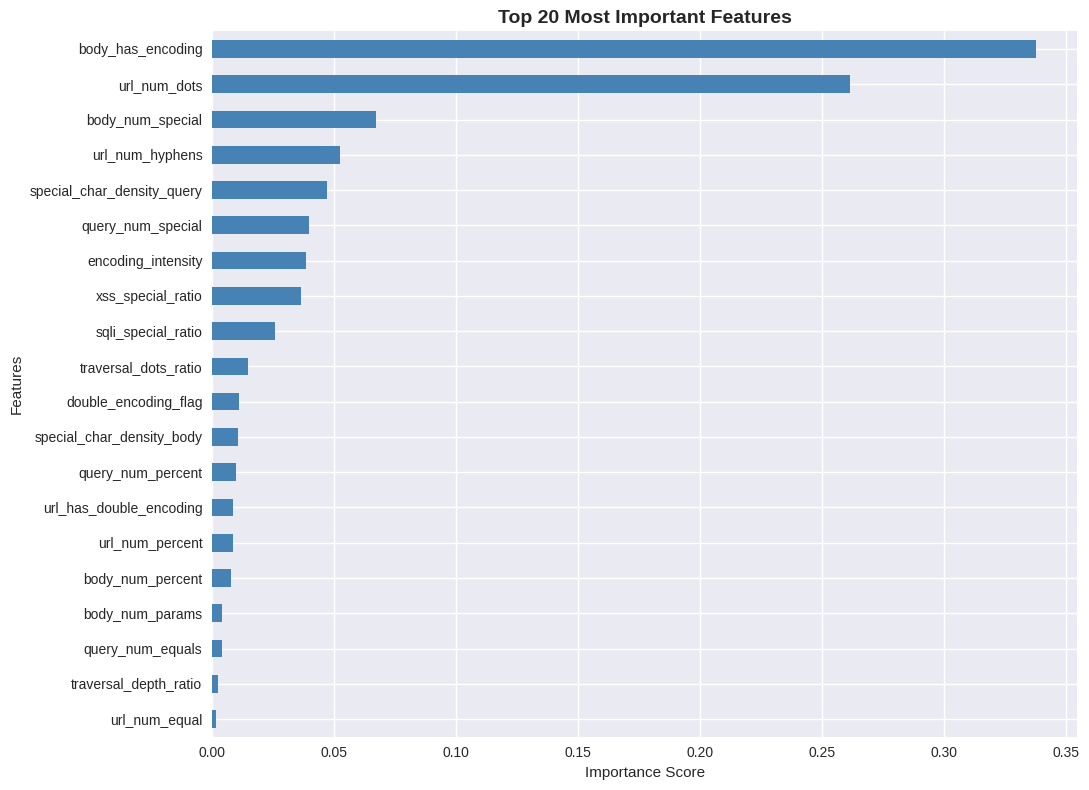


Top 15 Most Important Features:
body_has_encoding             0.33760
url_num_dots                  0.26144
body_num_special              0.06715
url_num_hyphens               0.05233
special_char_density_query    0.04720
query_num_special             0.03959
encoding_intensity            0.03835
xss_special_ratio             0.03629
sqli_special_ratio            0.02581
traversal_dots_ratio          0.01486
double_encoding_flag          0.01090
special_char_density_body     0.01070
query_num_percent             0.00983
url_has_double_encoding       0.00859
url_num_percent               0.00835
dtype: float32


In [78]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(11, 8))
top20.sort_values(ascending=True).plot(kind='barh', ax=ax, color='steelblue')

ax.set_title('Top 20 Most Important Features', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Features')

plt.tight_layout()
plt.savefig('model_diagnostics.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nTop 15 Most Important Features:")
print(importances.nlargest(15).round(5))